# Classificação - Treino/Teste

## Probabilísticas

### Regressão Logística

#### Treinando e Salvando Modelo -  Com 2 Classes

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import joblib

df = pd.read_csv("comentarios02.csv")
df.columns = [c.strip().lower() for c in df.columns]
comentario_col = [c for c in df.columns if "conteudo_comentario" in c][0]
nota_col = [c for c in df.columns if "nota_comentario" in c][0]

df = df[[comentario_col, nota_col]].dropna()
df[nota_col] = pd.to_numeric(df[nota_col].astype(str).str.replace(",", ".", regex=False), errors="coerce").round().clip(1,2) # Quantidade de classes
df[comentario_col] = df[comentario_col].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

X_train, X_test, y_train, y_test = train_test_split(
    df[comentario_col], df[nota_col].astype(int),
    test_size=0.2, random_state=42, stratify=df[nota_col]
)

joblib.dump((X_train, X_test, y_train, y_test), 'train_test_split_2_classes.pkl')

model = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, strip_accents="unicode", ngram_range=(1,2))),
    ("lr", LogisticRegression(max_iter=200, solver="lbfgs", multi_class="multinomial", class_weight="balanced"))
])

model.fit(X_train, y_train)
joblib.dump(model, "modelo_logreg_2_classes.pkl")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


['modelo_logreg_2_classes.pkl']

#### Treinando e Salvando Modelo -  Com 3 Classes

In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import joblib

df = pd.read_csv("comentarios03.csv")
df.columns = [c.strip().lower() for c in df.columns]
comentario_col = [c for c in df.columns if "conteudo_comentario" in c][0]
nota_col = [c for c in df.columns if "nota_comentario" in c][0]

df = df[[comentario_col, nota_col]].dropna()
df[nota_col] = pd.to_numeric(df[nota_col].astype(str).str.replace(",", ".", regex=False), errors="coerce").round().clip(1,3) # Quantidade de classes
df[comentario_col] = df[comentario_col].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

X_train, X_test, y_train, y_test = train_test_split(
    df[comentario_col], df[nota_col].astype(int),
    test_size=0.2, random_state=42, stratify=df[nota_col]
)

joblib.dump((X_train, X_test, y_train, y_test), 'train_test_split_3_classes.pkl')

model = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, strip_accents="unicode", ngram_range=(1,2))),
    ("lr", LogisticRegression(max_iter=200, solver="lbfgs", multi_class="multinomial", class_weight="balanced"))
])

model.fit(X_train, y_train)
joblib.dump(model, "modelo_logreg_3_classes.pkl")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


['modelo_logreg_3_classes.pkl']

#### Treinando e Salvando Modelo -  Com 5 Classes

In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import joblib

df = pd.read_csv("comentarios05.csv")
df.columns = [c.strip().lower() for c in df.columns]
comentario_col = [c for c in df.columns if "conteudo_comentario" in c][0]
nota_col = [c for c in df.columns if "nota_comentario" in c][0]

df = df[[comentario_col, nota_col]].dropna()
df[nota_col] = pd.to_numeric(df[nota_col].astype(str).str.replace(",", ".", regex=False), errors="coerce").round().clip(1,5) # Quantidade de classes
df[comentario_col] = df[comentario_col].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

X_train, X_test, y_train, y_test = train_test_split(
    df[comentario_col], df[nota_col].astype(int),
    test_size=0.2, random_state=42, stratify=df[nota_col]
)

joblib.dump((X_train, X_test, y_train, y_test), 'train_test_split_5_classes.pkl')

model = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, strip_accents="unicode", ngram_range=(1,2))),
    ("lr", LogisticRegression(max_iter=200, solver="lbfgs", multi_class="multinomial", class_weight="balanced"))
])

model.fit(X_train, y_train)
joblib.dump(model, "modelo_logreg_5_classes.pkl")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


['modelo_logreg_5_classes.pkl']

#### Métricas e Teste Manual com 2 Classes

In [38]:
# import joblib
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics import (mean_squared_error, mean_absolute_error, accuracy_score,
#                              confusion_matrix, classification_report)

# # Carregar modelo e dados
# model = joblib.load("modelo_logreg.pkl")
# X_train, X_test, y_train, y_test = joblib.load('train_test_split.pkl')

# # Fazer predições
# y_pred_lr = model.predict(X_test)

# # Calcular métricas
# mse = mean_squared_error(y_test, y_pred_lr)
# rmse = np.sqrt(mse)
# mae = mean_absolute_error(y_test, y_pred_lr)
# acc = accuracy_score(y_test, y_pred_lr)
# print(f"[LogisticRegression] RMSE={rmse:.3f}  MAE={mae:.3f}  ACC={acc:.3f}")

# # Calcular matriz de confusão e relatório
# classes = sorted(model.classes_)
# conf_matrix = confusion_matrix(y_test, y_pred_lr, labels=classes)

# # ===== PLOTAR MATRIZ DE CONFUSÃO E MÉTRICAS =====
# fig_height = max(6, len(classes) * 1.2)
# fig, axes = plt.subplots(1, 2, figsize=(15, fig_height))

# # Plot 1: Matriz de Confusão
# annot_fontsize = max(8, 14 - len(classes))
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
#             xticklabels=[f'Classe {c}' for c in classes],
#             yticklabels=[f'Classe {c}' for c in classes],
#             ax=axes[0], cbar_kws={'label': 'Contagem'},
#             annot_kws={'size': annot_fontsize})
# axes[0].set_title('Matriz de Confusão - Regressão Logística', fontsize=14, fontweight='bold')
# axes[0].set_ylabel('Valor Real', fontsize=12)
# axes[0].set_xlabel('Valor Predito', fontsize=12)

# # Plot 2: Métricas detalhadas
# report = classification_report(y_test, y_pred_lr, output_dict=True)
# metrics_text = f"""
# MÉTRICAS DE TESTE - REGRESSÃO LOGÍSTICA
# {'='*50}

# Acurácia:     {acc:.4f}
# RMSE:         {rmse:.4f}
# MAE:          {mae:.4f}

# {'='*50}
# MÉTRICAS POR CLASSE:
# {'='*50}
# """

# for cls in classes:
#     cls_str = str(float(cls))
#     if cls_str in report:
#         metrics_text += f"""
# CLASSE {cls}:
#   Precisão:   {report[cls_str]['precision']:.4f}
#   Recall:     {report[cls_str]['recall']:.4f}
#   F1-Score:   {report[cls_str]['f1-score']:.4f}
#   Suporte:    {int(report[cls_str]['support'])}
# """

# metrics_text += f"""
# {'='*50}
# MÉDIA PONDERADA:
#   Precisão:   {report['weighted avg']['precision']:.4f}
#   Recall:     {report['weighted avg']['recall']:.4f}
#   F1-Score:   {report['weighted avg']['f1-score']:.4f}
# """

# axes[1].text(0.05, 0.5, metrics_text, fontsize=10, family='monospace',
#              verticalalignment='center', transform=axes[1].transAxes)
# axes[1].axis('off')
# axes[1].set_title('Relatório de Classificação', fontsize=14, fontweight='bold')

# plt.tight_layout()
# plt.show()

# # Imprimir relatório completo no console
# print("\n" + "="*60)
# print("RELATÓRIO COMPLETO DE CLASSIFICAÇÃO")
# print("="*60)
# print(classification_report(y_test, y_pred_lr,
#                            target_names=[f'Classe {c}' for c in classes]))

# # Função de predição individual
# def predict_one_lr(text: str):
#     proba = model.predict_proba([text])[0]
#     idx = int(np.argmax(proba))
#     classes_model = model.classes_
#     return classes_model[idx], float(proba[idx]), dict(zip(classes_model, proba.tolist()))

# # Exemplos de predição
# print("\n" + "="*60)
# print("EXEMPLOS DE PREDIÇÕES")
# print("="*60)
# texts = [
#     "Gostei muito do filme, atuação excelente e trilha sonora incrível!",
#     "Roteiro fraco e previsível, me decepcionou bastante.",
#     "É ok. Nada impressionante, mas também não é ruim."
# ]
# for t in texts:
#     label, conf, probs = predict_one_lr(t)
#     print(f"\n{t}")
#     print(f" -> classe: {label} | confiança: {conf:.3f}")
#     print(f" -> probabilidades: {probs}")

# print("\n" + "="*60)

### Naive Bayes

#### Treinando e Salvando Modelo com 2 Classes

In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion
import joblib

df = pd.read_csv("comentarios02.csv")

df.columns = [c.strip().lower() for c in df.columns]
comentario_col = [c for c in df.columns if "conteudo_comentario" in c][0]
nota_col = [c for c in df.columns if "nota_comentario" in c][0]

df = df[[comentario_col, nota_col]].dropna()
df[nota_col] = pd.to_numeric(df[nota_col].astype(str).str.replace(",", ".", regex=False), errors="coerce").round().clip(1,2) # Quantidade de classes
df[comentario_col] = df[comentario_col].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

X_train, X_test, y_train, y_test = train_test_split(
    df[comentario_col], df[nota_col].astype(int),
    test_size=0.2, random_state=42, stratify=df[nota_col]
)

tfidf_union = FeatureUnion([
    ("word", TfidfVectorizer(strip_accents="unicode", lowercase=True)),
    ("char", TfidfVectorizer(analyzer="char_wb"))
])

pipe_nb = Pipeline([
    ("tfidf", tfidf_union),
    ("nb", MultinomialNB())
])

param_grid = {
    "tfidf__word__ngram_range": [(1,1), (1,2)],
    "tfidf__word__min_df": [1,2],
    "tfidf__char__ngram_range": [(3,5), (3,6)],
    "tfidf__char__min_df": [1,2],
    "nb__alpha": [0.1, 0.3, 0.5, 1.0]
}

grid = GridSearchCV(
    pipe_nb,
    param_grid,
    cv=3,
    n_jobs=-1,
    scoring="accuracy",
    verbose=1
)
grid.fit(X_train, y_train)

best_nb = grid.best_estimator_
joblib.dump(best_nb, "modelo_naivebayes_2_classes.pkl")
model = best_nb
print(f"Modelo Naive Bayes salvo: modelo_naivebayes.pkl  (best params: {grid.best_params_})")

Fitting 3 folds for each of 64 candidates, totalling 192 fits
Modelo Naive Bayes salvo: modelo_naivebayes.pkl  (best params: {'nb__alpha': 0.1, 'tfidf__char__min_df': 1, 'tfidf__char__ngram_range': (3, 5), 'tfidf__word__min_df': 1, 'tfidf__word__ngram_range': (1, 2)})


#### Treinando e Salvando Modelo com 3 Classes

In [40]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion
import joblib

df = pd.read_csv("comentarios03.csv")

df.columns = [c.strip().lower() for c in df.columns]
comentario_col = [c for c in df.columns if "conteudo_comentario" in c][0]
nota_col = [c for c in df.columns if "nota_comentario" in c][0]

df = df[[comentario_col, nota_col]].dropna()
df[nota_col] = pd.to_numeric(df[nota_col].astype(str).str.replace(",", ".", regex=False), errors="coerce").round().clip(1,3) # Quantidade de classes
df[comentario_col] = df[comentario_col].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

X_train, X_test, y_train, y_test = train_test_split(
    df[comentario_col], df[nota_col].astype(int),
    test_size=0.2, random_state=42, stratify=df[nota_col]
)

tfidf_union = FeatureUnion([
    ("word", TfidfVectorizer(strip_accents="unicode", lowercase=True)),
    ("char", TfidfVectorizer(analyzer="char_wb"))
])

pipe_nb = Pipeline([
    ("tfidf", tfidf_union),
    ("nb", MultinomialNB())
])

param_grid = {
    "tfidf__word__ngram_range": [(1,1), (1,2)],
    "tfidf__word__min_df": [1,2],
    "tfidf__char__ngram_range": [(3,5), (3,6)],
    "tfidf__char__min_df": [1,2],
    "nb__alpha": [0.1, 0.3, 0.5, 1.0]
}

grid = GridSearchCV(
    pipe_nb,
    param_grid,
    cv=3,
    n_jobs=-1,
    scoring="accuracy",
    verbose=1
)
grid.fit(X_train, y_train)

best_nb = grid.best_estimator_
joblib.dump(best_nb, "modelo_naivebayes_3_classes.pkl")
model = best_nb
print(f"Modelo Naive Bayes salvo: modelo_naivebayes.pkl  (best params: {grid.best_params_})")

Fitting 3 folds for each of 64 candidates, totalling 192 fits
Modelo Naive Bayes salvo: modelo_naivebayes.pkl  (best params: {'nb__alpha': 0.1, 'tfidf__char__min_df': 1, 'tfidf__char__ngram_range': (3, 5), 'tfidf__word__min_df': 2, 'tfidf__word__ngram_range': (1, 2)})


#### Treinando e Salvando Modelo com 5 Classes

In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion
import joblib

df = pd.read_csv("comentarios05.csv")

df.columns = [c.strip().lower() for c in df.columns]
comentario_col = [c for c in df.columns if "conteudo_comentario" in c][0]
nota_col = [c for c in df.columns if "nota_comentario" in c][0]

df = df[[comentario_col, nota_col]].dropna()
df[nota_col] = pd.to_numeric(df[nota_col].astype(str).str.replace(",", ".", regex=False), errors="coerce").round().clip(1,5) # Quantidade de classes
df[comentario_col] = df[comentario_col].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

X_train, X_test, y_train, y_test = train_test_split(
    df[comentario_col], df[nota_col].astype(int),
    test_size=0.2, random_state=42, stratify=df[nota_col]
)

tfidf_union = FeatureUnion([
    ("word", TfidfVectorizer(strip_accents="unicode", lowercase=True)),
    ("char", TfidfVectorizer(analyzer="char_wb"))
])

pipe_nb = Pipeline([
    ("tfidf", tfidf_union),
    ("nb", MultinomialNB())
])

param_grid = {
    "tfidf__word__ngram_range": [(1,1), (1,2)],
    "tfidf__word__min_df": [1,2],
    "tfidf__char__ngram_range": [(3,5), (3,6)],
    "tfidf__char__min_df": [1,2],
    "nb__alpha": [0.1, 0.3, 0.5, 1.0]
}

grid = GridSearchCV(
    pipe_nb,
    param_grid,
    cv=3,
    n_jobs=-1,
    scoring="accuracy",
    verbose=1
)
grid.fit(X_train, y_train)

best_nb = grid.best_estimator_
joblib.dump(best_nb, "modelo_naivebayes_5_classes.pkl")
model = best_nb
print(f"Modelo Naive Bayes salvo: modelo_naivebayes.pkl  (best params: {grid.best_params_})")

Fitting 3 folds for each of 64 candidates, totalling 192 fits
Modelo Naive Bayes salvo: modelo_naivebayes.pkl  (best params: {'nb__alpha': 0.1, 'tfidf__char__min_df': 2, 'tfidf__char__ngram_range': (3, 5), 'tfidf__word__min_df': 2, 'tfidf__word__ngram_range': (1, 1)})


#### Métricas e Teste Manual

In [42]:
# import joblib
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics import (mean_squared_error, mean_absolute_error, accuracy_score,
#                              confusion_matrix, classification_report)

# # Carregar modelo e dados
# model = joblib.load("modelo_naivebayes.pkl")
# X_train, X_test, y_train, y_test = joblib.load('train_test_split.pkl')

# # Fazer predições
# y_pred_nb = model.predict(X_test)

# # Calcular métricas
# mse = mean_squared_error(y_test, y_pred_nb)
# rmse = np.sqrt(mse)
# mae = mean_absolute_error(y_test, y_pred_nb)
# acc = accuracy_score(y_test, y_pred_nb)
# print(f"[NaiveBayes] RMSE={rmse:.3f}  MAE={mae:.3f}  ACC={acc:.3f}")

# # Calcular matriz de confusão e relatório
# conf_matrix = confusion_matrix(y_test, y_pred_nb)
# classes = sorted(model.classes_)

# # ===== PLOTAR MATRIZ DE CONFUSÃO E MÉTRICAS =====
# fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# # Plot 1: Matriz de Confusão
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens',
#             xticklabels=[f'Classe {c}' for c in classes],
#             yticklabels=[f'Classe {c}' for c in classes],
#             ax=axes[0], cbar_kws={'label': 'Contagem'})
# axes[0].set_title('Matriz de Confusão - Naive Bayes', fontsize=14, fontweight='bold')
# axes[0].set_ylabel('Valor Real', fontsize=12)
# axes[0].set_xlabel('Valor Predito', fontsize=12)

# # Plot 2: Métricas detalhadas
# report = classification_report(y_test, y_pred_nb, output_dict=True)
# metrics_text = f"""
# MÉTRICAS DE TESTE - NAIVE BAYES
# {'='*50}

# Acurácia:     {acc:.4f}
# RMSE:         {rmse:.4f}
# MAE:          {mae:.4f}

# {'='*50}
# MÉTRICAS POR CLASSE:
# {'='*50}
# """

# for cls in classes:
#     cls_str = str(float(cls))
#     if cls_str in report:
#         metrics_text += f"""
# CLASSE {cls}:
#   Precisão:   {report[cls_str]['precision']:.4f}
#   Recall:     {report[cls_str]['recall']:.4f}
#   F1-Score:   {report[cls_str]['f1-score']:.4f}
#   Suporte:    {int(report[cls_str]['support'])}
# """

# metrics_text += f"""
# {'='*50}
# MÉDIA PONDERADA:
#   Precisão:   {report['weighted avg']['precision']:.4f}
#   Recall:     {report['weighted avg']['recall']:.4f}
#   F1-Score:   {report['weighted avg']['f1-score']:.4f}
# """

# axes[1].text(0.05, 0.5, metrics_text, fontsize=10, family='monospace',
#              verticalalignment='center', transform=axes[1].transAxes)
# axes[1].axis('off')
# axes[1].set_title('Relatório de Classificação', fontsize=14, fontweight='bold')

# plt.tight_layout()
# plt.show()

# # Imprimir relatório completo no console
# print("\n" + "="*60)
# print("RELATÓRIO COMPLETO DE CLASSIFICAÇÃO")
# print("="*60)
# print(classification_report(y_test, y_pred_nb,
#                            target_names=[f'Classe {c}' for c in classes]))

# # Função de predição individual
# def predict_one_nb(text: str):
#     proba = model.predict_proba([text])[0]
#     idx = int(np.argmax(proba))
#     classes_model = model.classes_
#     return classes_model[idx], float(proba[idx]), dict(zip(classes_model, proba.tolist()))

# # Exemplos de predição
# print("\n" + "="*60)
# print("EXEMPLOS DE PREDIÇÕES")
# print("="*60)
# texts = [
#     "Gostei muito do filme, atuação excelente e trilha sonora incrível!",
#     "Roteiro fraco e previsível, me decepcionou bastante.",
#     "É ok. Nada impressionante, mas também não é ruim."
# ]
# for t in texts:
#     label, conf, probs = predict_one_nb(t)
#     print(f"\n{t}")
#     print(f" -> classe: {label} | confiança: {conf:.3f}")
#     print(f" -> probabilidades: {probs}")

# print("\n" + "="*60)

## Redes Neurais

## BERT

### Importando Bibliotecas

In [43]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


### Configuração e Carregar Dados de 2, 3 e 5 classes

In [44]:
model_name = "neuralmind/bert-base-portuguese-cased"
max_len = 256
batch_size = 16
epochs = 3
lr = 2e-5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset 2 classes
df_02 = pd.read_csv("comentarios02.csv")
df_02 = pd.DataFrame({
    "comentario": df_02["conteudo_comentario"].astype(str).str.replace(r"\s+"," ",regex=True).str.strip(),
    "nota": pd.to_numeric(df_02["nota_comentario"].astype(str).str.replace(",",".",regex=False), errors="coerce")
})
df_02["nota"] = df_02["nota"].round().clip(1,2).dropna()

# Dataset 3 classes
df_03 = pd.read_csv("comentarios03.csv")
df_03 = pd.DataFrame({
    "comentario": df_03["conteudo_comentario"].astype(str).str.replace(r"\s+"," ",regex=True).str.strip(),
    "nota": pd.to_numeric(df_03["nota_comentario"].astype(str).str.replace(",",".",regex=False), errors="coerce")
})
df_03["nota"] = df_03["nota"].round().clip(1,3).dropna()

# Dataset 5 classes
df_05 = pd.read_csv("comentarios05.csv")
df_05 = pd.DataFrame({
    "comentario": df_05["conteudo_comentario"].astype(str).str.replace(r"\s+"," ",regex=True).str.strip(),
    "nota": pd.to_numeric(df_05["nota_comentario"].astype(str).str.replace(",",".",regex=False), errors="coerce")
})
df_05["nota"] = df_05["nota"].round().clip(1,5).dropna()

datasets_config = [
    (df_02, 2, "2_classes"),
    (df_03, 3, "3_classes"),
    (df_05, 5, "5_classes")
]

### Treinando Rede Neural - BERT

In [45]:
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

class TextClassDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = list(texts)
        self.labels = np.array(labels, dtype=np.int64)
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        enc = self.tok(
            self.texts[i],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["label"] = torch.tensor(self.labels[i], dtype=torch.long)
        return item

class BERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden = self.bert.config.hidden_size
        self.dropout = nn.Dropout(0.1)
        self.head = nn.Linear(hidden, num_classes)

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = out.last_hidden_state
        mask = attention_mask.unsqueeze(-1)
        masked = last_hidden * mask
        pooled = masked.sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        x = self.dropout(pooled)
        return self.head(x)

resultados = []

for df, num_classes, label in datasets_config:
    print(f"\n{'='*80}")
    print(f"🚀 TREINANDO BERT - {label.upper()}")
    print(f"{'='*80}\n")

    # Split dos dados
    X_train, X_test, y_train, y_test = train_test_split(
        df["comentario"],
        df["nota"].astype(int) - 1,  # Converter para 0-indexed
        test_size=0.2,
        random_state=42,
        stratify=df["nota"]
    )

    # Salvar split
    joblib.dump((X_train, X_test, y_train, y_test), f'train_test_split_bert_{label}.pkl')

    # Criar datasets
    train_ds = TextClassDataset(X_train, y_train, tokenizer, max_len)
    test_ds = TextClassDataset(X_test, y_test, tokenizer, max_len)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    # Criar modelo
    model = BERTClassifier(model_name, num_classes).to(device)

    # Otimizador e scheduler
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )
    loss_fn = nn.CrossEntropyLoss()

    # Treinamento
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attn = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids=input_ids, attention_mask=attn)
            loss = loss_fn(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        acc_train = correct / total
        print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f} - Acc: {acc_train:.4f}")

    # Avaliação
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attn = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(input_ids=input_ids, attention_mask=attn)
            _, predicted = torch.max(logits, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Converter de volta para 1-indexed
    y_test_original = np.array(all_labels) + 1
    y_pred_original = np.array(all_preds) + 1

    # Calcular métricas
    acc = accuracy_score(all_labels, all_preds)
    conf_matrix = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, output_dict=True, zero_division=0)

    print(f"\n✅ [BERT {label}] Acurácia: {acc:.4f}")

    # Salvar modelo
    torch.save(model.state_dict(), f'modelo_bert_{label}.pth')

    # Armazenar resultados
    resultados.append({
        'label': label,
        'num_classes': num_classes,
        'model': model,
        'y_test': y_test_original,
        'y_pred': y_pred_original,
        'acc': acc,
        'conf_matrix': conf_matrix,
        'report': report,
        'X_test': X_test
    })


🚀 TREINANDO BERT - 2_CLASSES

Epoch 1/3 - Loss: 0.6371 - Acc: 0.6057
Epoch 2/3 - Loss: 0.4600 - Acc: 0.7739
Epoch 3/3 - Loss: 0.3273 - Acc: 0.8642

✅ [BERT 2_classes] Acurácia: 0.7908

🚀 TREINANDO BERT - 3_CLASSES

Epoch 1/3 - Loss: 0.9962 - Acc: 0.4599
Epoch 2/3 - Loss: 0.7612 - Acc: 0.6397
Epoch 3/3 - Loss: 0.6060 - Acc: 0.7276

✅ [BERT 3_classes] Acurácia: 0.6431

🚀 TREINANDO BERT - 5_CLASSES

Epoch 1/3 - Loss: 1.4436 - Acc: 0.3827
Epoch 2/3 - Loss: 1.1002 - Acc: 0.5370
Epoch 3/3 - Loss: 0.9046 - Acc: 0.6165

✅ [BERT 5_classes] Acurácia: 0.5046


# Matrizes de Confusão e Relatórios de Classificação


                              REGRESSÃO LOGÍSTICA                               


────────────────────────────────────────────────────────────────────────────────
 Regressão Logística - 2 Classes
────────────────────────────────────────────────────────────────────────────────

📊 Acurácia: 0.7438

📈 Relatório de Classificação:
              precision    recall  f1-score   support

    Classe 1       0.75      0.74      0.75       166
    Classe 2       0.73      0.75      0.74       158

    accuracy                           0.74       324
   macro avg       0.74      0.74      0.74       324
weighted avg       0.74      0.74      0.74       324


🔮 Exemplos de Predições:
────────────────────────────────────────────────────────────────────────────────

📝 "Gostei muito do filme, atuação excelente e trilha sonora inc..."
   ➜ Classe: 2 | Confiança: 0.755
   ➜ Probabilidades: {np.int64(1): 0.24542145795502346, np.int64(2): 0.7545785420449765}

📝 "Roteiro fraco e previsível, me decepcion

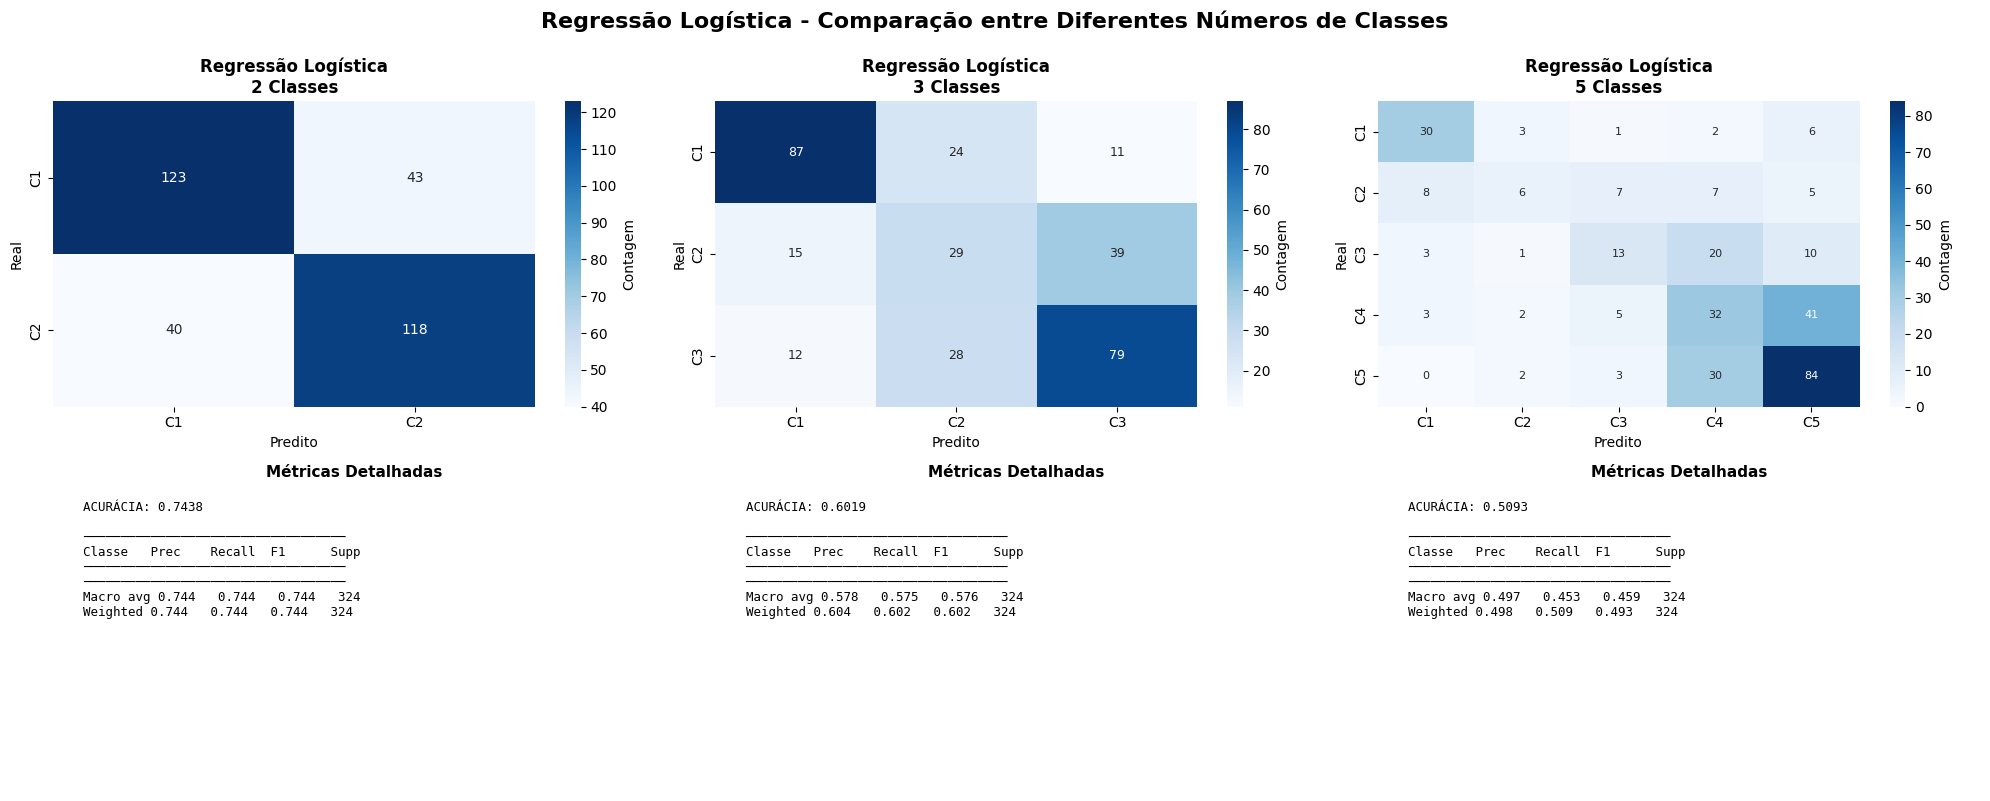


                                  NAIVE BAYES                                   


────────────────────────────────────────────────────────────────────────────────
 Naive Bayes - 2 Classes
────────────────────────────────────────────────────────────────────────────────

📊 Acurácia: 0.7438

📈 Relatório de Classificação:
              precision    recall  f1-score   support

    Classe 1       0.78      0.69      0.73       166
    Classe 2       0.71      0.80      0.75       158

    accuracy                           0.74       324
   macro avg       0.75      0.75      0.74       324
weighted avg       0.75      0.74      0.74       324


🔮 Exemplos de Predições:
────────────────────────────────────────────────────────────────────────────────

📝 "Gostei muito do filme, atuação excelente e trilha sonora inc..."
   ➜ Classe: 2 | Confiança: 0.997
   ➜ Probabilidades: {np.int64(1): 0.003241566628060274, np.int64(2): 0.9967584333719257}

📝 "Roteiro fraco e previsível, me decepcionou bast

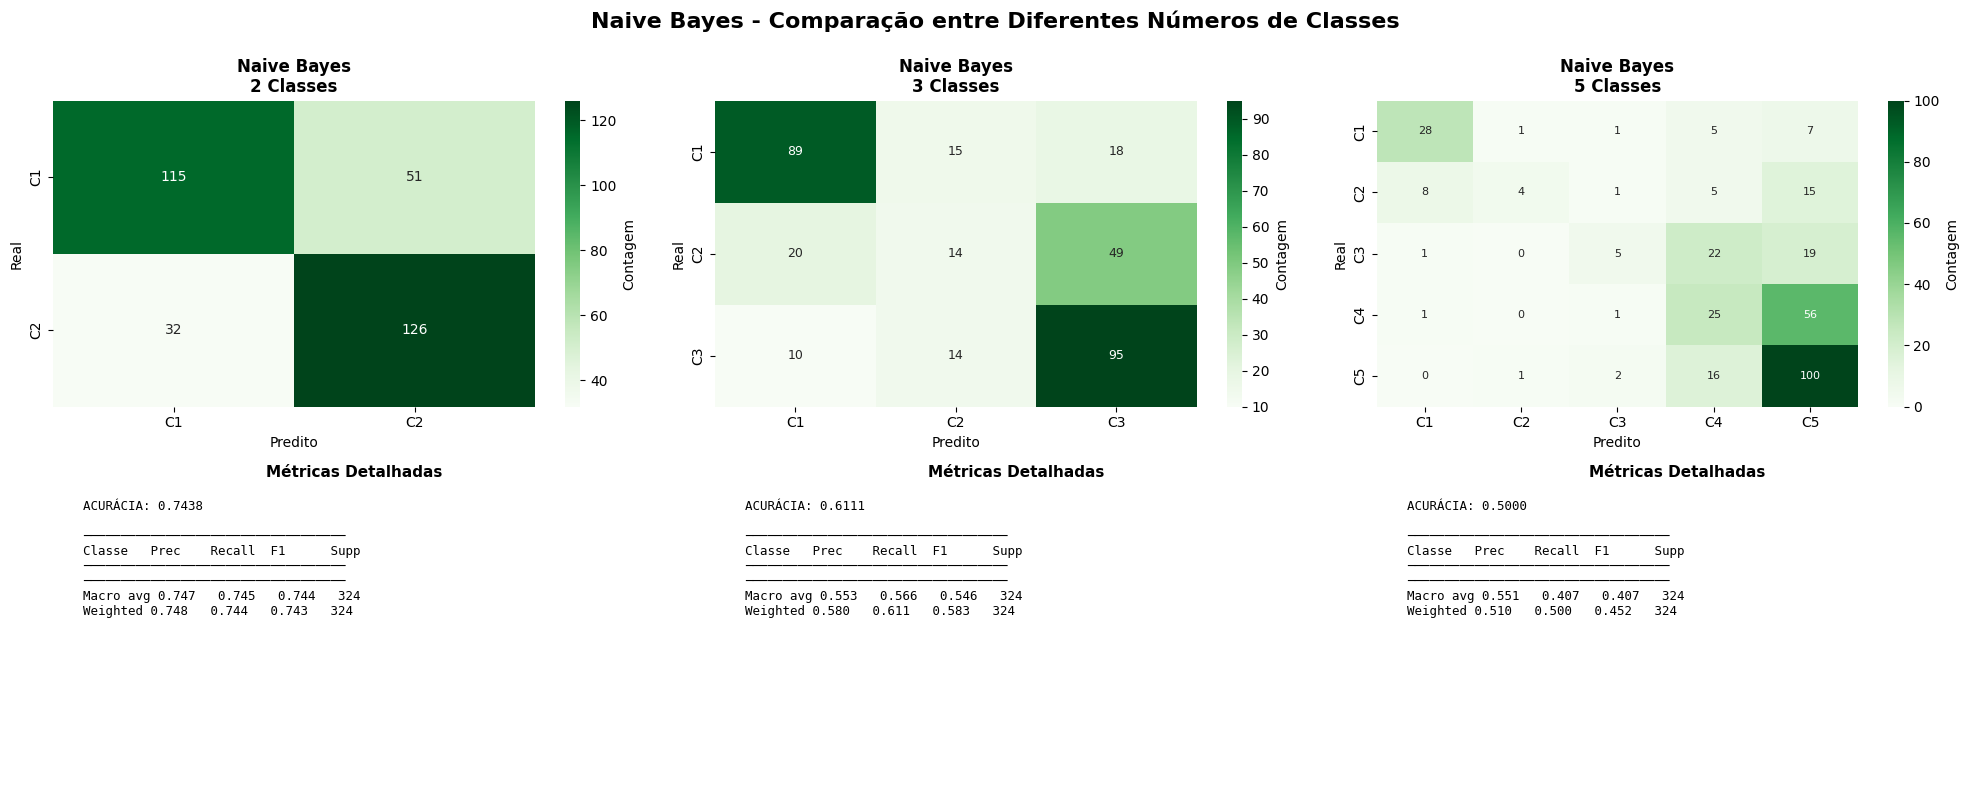


                                      BERT                                      


────────────────────────────────────────────────────────────────────────────────
 BERT - 2 Classes
────────────────────────────────────────────────────────────────────────────────

📊 Acurácia: 0.7908

📈 Relatório de Classificação:
              precision    recall  f1-score   support

    Classe 1       0.82      0.76      0.79       166
    Classe 2       0.77      0.82      0.79       159

    accuracy                           0.79       325
   macro avg       0.79      0.79      0.79       325
weighted avg       0.79      0.79      0.79       325


🔮 Exemplos de Predições:
────────────────────────────────────────────────────────────────────────────────

📝 "Gostei muito do filme, atuação excelente e trilha sonora inc..."
   ➜ Classe: 2 | Confiança: 0.839
   ➜ Probabilidades: {1: 0.1609046906232834, 2: 0.8390953540802002}

📝 "Roteiro fraco e previsível, me decepcionou bastante."
   ➜ Classe: 1 | Confi

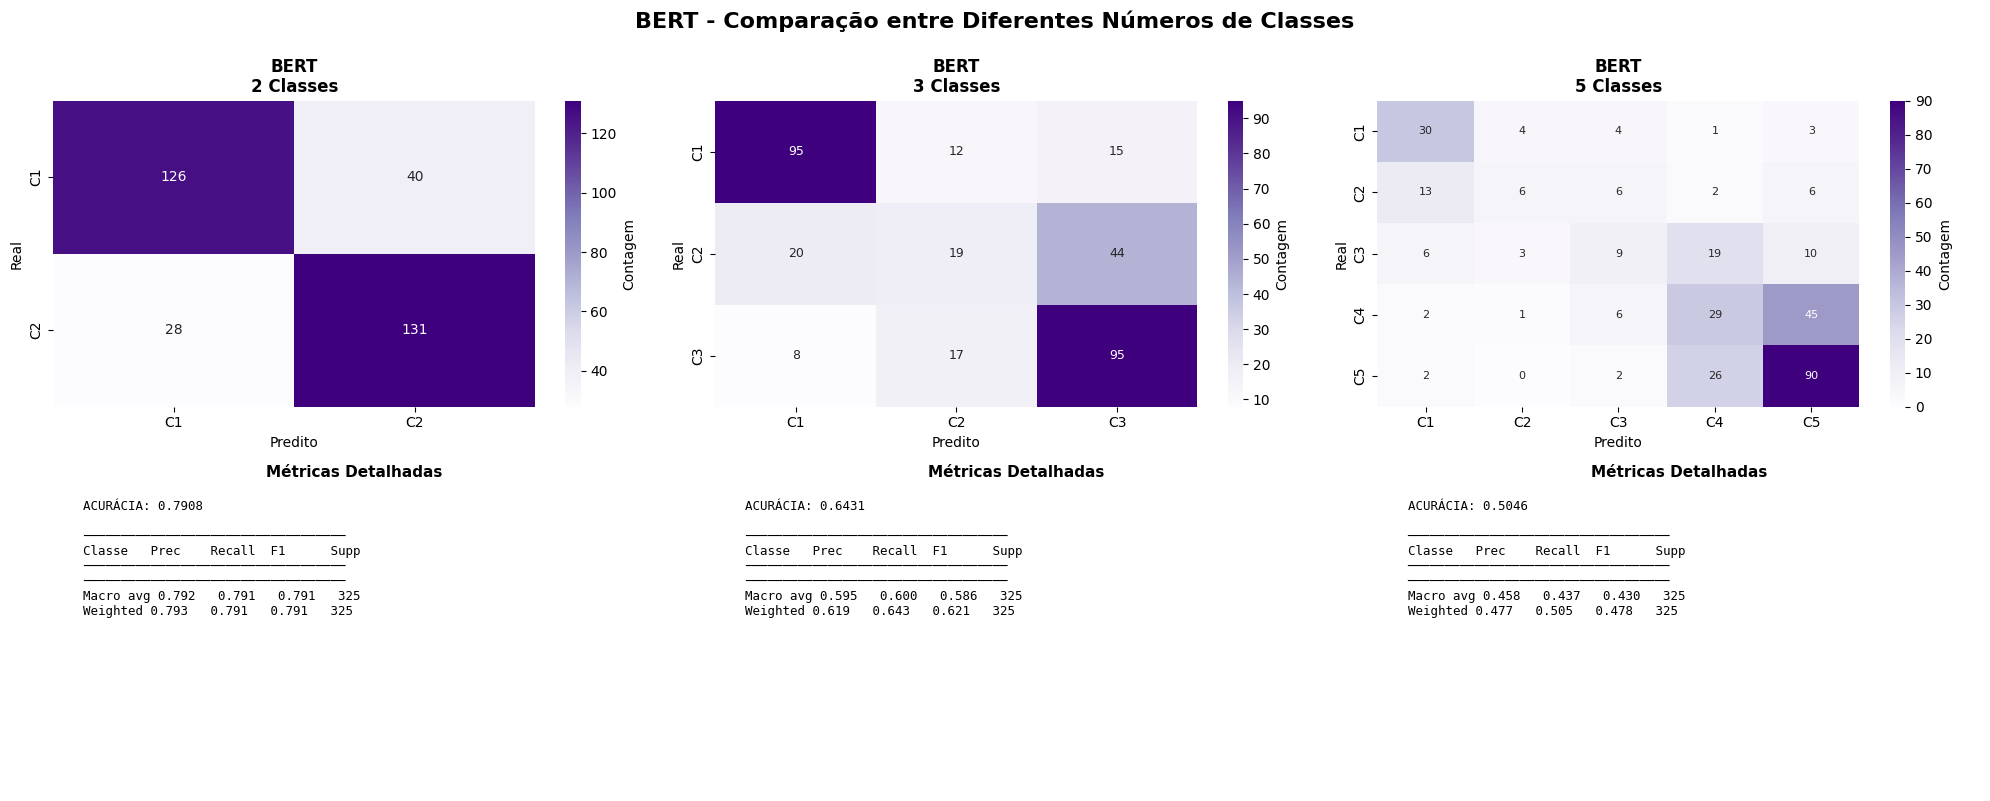


✅ ANÁLISE COMPLETA FINALIZADA - TODOS OS MÉTODOS


In [48]:
import joblib
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from transformers import AutoTokenizer, AutoModel

# ============================================================================
# CONFIGURAÇÕES PARA BERT
# ============================================================================
model_name = "neuralmind/bert-base-portuguese-cased"
max_len = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Carregar tokenizer para BERT
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

# Classe do modelo BERT
class BERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden = self.bert.config.hidden_size
        self.dropout = nn.Dropout(0.1)
        self.head = nn.Linear(hidden, num_classes)

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = out.last_hidden_state
        mask = attention_mask.unsqueeze(-1)
        masked = last_hidden * mask
        pooled = masked.sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        x = self.dropout(pooled)
        return self.head(x)

# ============================================================================
# CONFIGURAÇÕES DOS MODELOS
# ============================================================================
modelos_configs = [
    {
        'nome': 'Regressão Logística',
        'modelos': [
            ('modelo_logreg_2_classes.pkl', 'train_test_split_2_classes.pkl', '2 Classes', 'sklearn'),
            ('modelo_logreg_3_classes.pkl', 'train_test_split_3_classes.pkl', '3 Classes', 'sklearn'),
            ('modelo_logreg_5_classes.pkl', 'train_test_split_5_classes.pkl', '5 Classes', 'sklearn')
        ],
        'cor': 'Blues'
    },
    {
        'nome': 'Naive Bayes',
        'modelos': [
            ('modelo_naivebayes_2_classes.pkl', 'train_test_split_2_classes.pkl', '2 Classes', 'sklearn'),
            ('modelo_naivebayes_3_classes.pkl', 'train_test_split_3_classes.pkl', '3 Classes', 'sklearn'),
            ('modelo_naivebayes_5_classes.pkl', 'train_test_split_5_classes.pkl', '5 Classes', 'sklearn')
        ],
        'cor': 'Greens'
    },
    {
        'nome': 'BERT',
        'modelos': [
            ('modelo_bert_2_classes.pth', 'train_test_split_bert_2_classes.pkl', '2 Classes', 'bert', 2),
            ('modelo_bert_3_classes.pth', 'train_test_split_bert_3_classes.pkl', '3 Classes', 'bert', 3),
            ('modelo_bert_5_classes.pth', 'train_test_split_bert_5_classes.pkl', '5 Classes', 'bert', 5)
        ],
        'cor': 'Purples'
    }
]

# Textos para teste
textos_teste = [
    "Gostei muito do filme, atuação excelente e trilha sonora incrível!",
    "Roteiro fraco e previsível, me decepcionou bastante.",
    "É ok. Nada impressionante, mas também não é ruim."
]

# ============================================================================
# PROCESSAR CADA MÉTODO
# ============================================================================
for metodo in modelos_configs:
    print("\n" + "="*80)
    print(f"{'='*80}")
    print(f"{metodo['nome'].upper():^80}")
    print(f"{'='*80}")
    print("="*80 + "\n")

    # Criar figura com 3 colunas (uma para cada número de classes)
    fig = plt.figure(figsize=(20, 8))

    for idx, modelo_info in enumerate(metodo['modelos'], 1):
        modelo_path, dados_path, n_classes_label, tipo = modelo_info[:4]

        print(f"\n{'─'*80}")
        print(f" {metodo['nome']} - {n_classes_label}")
        print(f"{'─'*80}")

        # Carregar dados
        try:
            X_train, X_test, y_train, y_test = joblib.load(dados_path)
        except FileNotFoundError:
            print(f"❌ Arquivo não encontrado: {dados_path}")
            continue

        # Carregar modelo e fazer predições
        if tipo == 'sklearn':
            try:
                model = joblib.load(modelo_path)
                y_pred = model.predict(X_test)
                classes = sorted(model.classes_)
                y_test_plot = y_test
                y_pred_plot = y_pred
            except FileNotFoundError:
                print(f"❌ Arquivo não encontrado: {modelo_path}")
                continue

        else:  # BERT
            num_classes = modelo_info[4]
            try:
                model = BERTClassifier(model_name, num_classes).to(device)
                model.load_state_dict(torch.load(modelo_path, map_location=device))
                model.eval()

                # Fazer predições
                all_preds = []
                with torch.no_grad():
                    for texto in X_test:
                        enc = tokenizer(
                            texto,
                            truncation=True,
                            padding="max_length",
                            max_length=max_len,
                            return_tensors="pt"
                        )
                        input_ids = enc["input_ids"].to(device)
                        attn = enc["attention_mask"].to(device)
                        logits = model(input_ids=input_ids, attention_mask=attn)
                        _, predicted = torch.max(logits, 1)
                        all_preds.append(predicted.cpu().numpy()[0])

                # Converter para 1-indexed para exibição
                y_pred_plot = np.array(all_preds) + 1
                y_test_plot = np.array(y_test) + 1
                classes = list(range(1, num_classes + 1))
            except FileNotFoundError:
                print(f"❌ Arquivo não encontrado: {modelo_path}")
                continue

        # Calcular métricas
        conf_matrix = confusion_matrix(y_test_plot, y_pred_plot, labels=classes)
        report = classification_report(y_test_plot, y_pred_plot, output_dict=True, zero_division=0)
        acc = accuracy_score(y_test_plot, y_pred_plot)

        # ===== SUBPLOT: MATRIZ DE CONFUSÃO =====
        ax = plt.subplot(2, 3, idx)
        annot_fontsize = max(8, 12 - len(classes))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap=metodo['cor'],
                    xticklabels=[f'C{c}' for c in classes],
                    yticklabels=[f'C{c}' for c in classes],
                    ax=ax, cbar_kws={'label': 'Contagem'},
                    annot_kws={'size': annot_fontsize})
        ax.set_title(f'{metodo["nome"]}\n{n_classes_label}', fontsize=12, fontweight='bold')
        ax.set_ylabel('Real', fontsize=10)
        ax.set_xlabel('Predito', fontsize=10)

        # ===== SUBPLOT: RELATÓRIO DE MÉTRICAS =====
        ax2 = plt.subplot(2, 3, idx + 3)

        # Montar texto do relatório
        relatorio_texto = f"ACURÁCIA: {acc:.4f}\n\n"
        relatorio_texto += f"{'─'*35}\n"
        relatorio_texto += f"{'Classe':<8} {'Prec':<7} {'Recall':<7} {'F1':<7} {'Supp':<6}\n"
        relatorio_texto += f"{'─'*35}\n"

        for cls in classes:
            cls_str = str(float(cls))
            if cls_str in report:
                relatorio_texto += f"{int(cls):<8} "
                relatorio_texto += f"{report[cls_str]['precision']:<7.3f} "
                relatorio_texto += f"{report[cls_str]['recall']:<7.3f} "
                relatorio_texto += f"{report[cls_str]['f1-score']:<7.3f} "
                relatorio_texto += f"{int(report[cls_str]['support']):<6}\n"

        relatorio_texto += f"{'─'*35}\n"
        relatorio_texto += f"{'Macro avg':<8} "
        relatorio_texto += f"{report['macro avg']['precision']:<7.3f} "
        relatorio_texto += f"{report['macro avg']['recall']:<7.3f} "
        relatorio_texto += f"{report['macro avg']['f1-score']:<7.3f} "
        relatorio_texto += f"{int(report['macro avg']['support']):<6}\n"

        relatorio_texto += f"{'Weighted':<8} "
        relatorio_texto += f"{report['weighted avg']['precision']:<7.3f} "
        relatorio_texto += f"{report['weighted avg']['recall']:<7.3f} "
        relatorio_texto += f"{report['weighted avg']['f1-score']:<7.3f} "
        relatorio_texto += f"{int(report['weighted avg']['support']):<6}\n"

        ax2.text(0.05, 0.95, relatorio_texto, fontsize=9, family='monospace',
                 verticalalignment='top', transform=ax2.transAxes)
        ax2.axis('off')
        ax2.set_title('Métricas Detalhadas', fontsize=11, fontweight='bold')

        # ===== IMPRIMIR NO CONSOLE =====
        print(f"\n📊 Acurácia: {acc:.4f}")
        print(f"\n📈 Relatório de Classificação:")
        print(classification_report(y_test_plot, y_pred_plot,
                                   target_names=[f'Classe {c}' for c in classes],
                                   zero_division=0))

        # ===== EXEMPLOS DE PREDIÇÃO =====
        print(f"\n🔮 Exemplos de Predições:")
        print(f"{'─'*80}")

        for texto in textos_teste:
            if tipo == 'sklearn':
                proba = model.predict_proba([texto])[0]
                pred_idx = int(np.argmax(proba))
                pred_classe = model.classes_[pred_idx]
                pred_conf = float(proba[pred_idx])
                probs_dict = dict(zip(model.classes_, proba.tolist()))
            else:  # BERT
                enc = tokenizer(
                    texto,
                    truncation=True,
                    padding="max_length",
                    max_length=max_len,
                    return_tensors="pt"
                )
                with torch.no_grad():
                    input_ids = enc["input_ids"].to(device)
                    attn = enc["attention_mask"].to(device)
                    logits = model(input_ids=input_ids, attention_mask=attn)
                    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
                    pred_idx = np.argmax(probs)
                    pred_classe = pred_idx + 1
                    pred_conf = probs[pred_idx]
                    probs_dict = {c: float(probs[c-1]) for c in classes}

            print(f"\n📝 \"{texto[:60]}...\"" if len(texto) > 60 else f"\n📝 \"{texto}\"")
            print(f"   ➜ Classe: {pred_classe} | Confiança: {pred_conf:.3f}")
            print(f"   ➜ Probabilidades: {probs_dict}")

    plt.suptitle(f'{metodo["nome"]} - Comparação entre Diferentes Números de Classes',
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print("✅ ANÁLISE COMPLETA FINALIZADA - TODOS OS MÉTODOS")
print("="*80)